In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
path = '/content/drive/MyDrive/Notebook Capstone Final/Dataset/'

# Load df_combined yang sudah direbuild (tanpa df2)
df = pd.read_csv(path + 'Data_Final_Combine.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Pisahkan EXPENSE dan INCOME
df_expense = df[df['Transaction_Type'] == 'EXPENSE'].copy()
df_income  = df[df['Transaction_Type'] == 'INCOME'].copy()

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Setup selesai!")
print(f"Total data    : {df.shape[0]} baris")
print(f"Total expense : {df_expense.shape[0]} baris")
print(f"Total income  : {df_income.shape[0]} baris")
print()
print("Statistik Amount:")
print(df['Amount'].describe())

✅ Setup selesai!
Total data    : 4981 baris
Total expense : 4747 baris
Total income  : 234 baris

Statistik Amount:
count    4.981000e+03
mean     6.815860e+04
std      2.433067e+05
min      3.142000e+01
25%      1.146600e+04
50%      2.159400e+04
75%      3.755600e+04
max      2.974435e+06
Name: Amount, dtype: float64


## Business Questions

Berdasarkan dataset transaksi keuangan mahasiswa, berikut adalah
pertanyaan bisnis yang ingin dijawab melalui proses EDA:

1. Kategori apa yang paling menguras pengeluaran mahasiswa?
2. Bulan mana pengeluaran mahasiswa paling tinggi?
3. Hari apa mahasiswa paling boros dalam seminggu?
4. Berapa rata-rata pengeluaran harian mahasiswa?
5. Bagaimana perbandingan total pemasukan vs pengeluaran?
6. Kategori apa yang paling sering transaksi vs paling besar nominalnya?
7. Bagaimana Pola Pengeluaran Mahasiswa Berdasarkan Data Asli?

# Exploratory Data Analysis

In [9]:
# EDA 1 — DISTRIBUSI TRANSAKSI

print("📊 Distribusi Transaksi:")
print(df['Transaction_Type'].value_counts())
print()
print("📊 Distribusi Kategori:")
print(df['Category'].value_counts())

📊 Distribusi Transaksi:
Transaction_Type
EXPENSE    4747
INCOME      234
Name: count, dtype: int64

📊 Distribusi Kategori:
Category
Makan & Minum    2588
Tagihan           637
Belanja           598
Lain-lain         524
Hiburan           400
Gaji              136
Goals              98
Name: count, dtype: int64


/tmp/ipykernel_1263/3533409718.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_count.values, y=cat_count.index,
/tmp/ipykernel_1263/3533409718.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_amount.values, y=cat_amount.index,


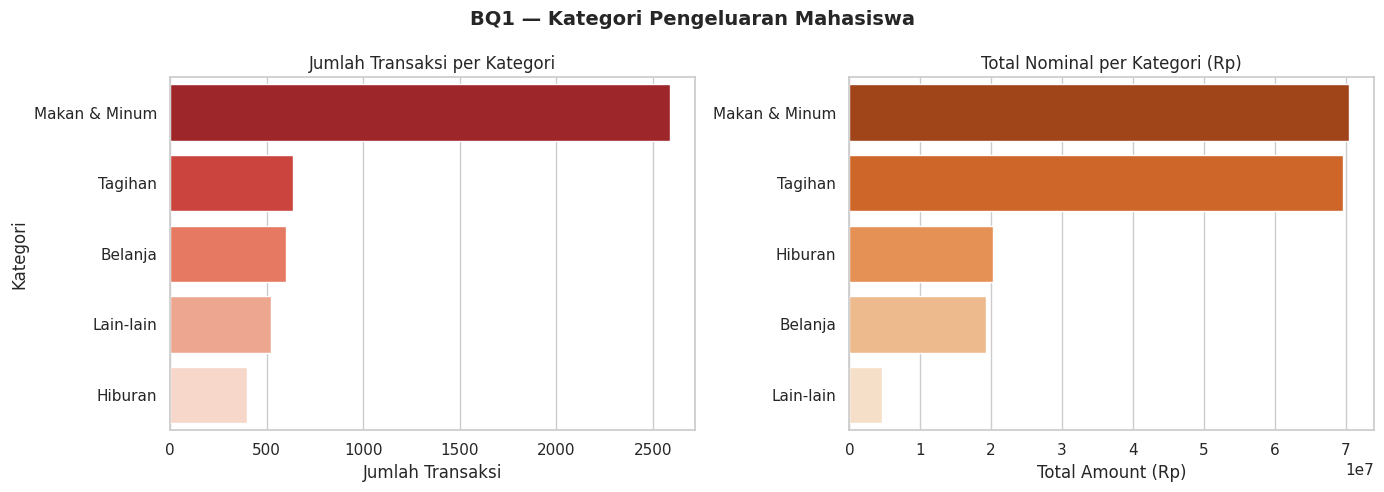

💡 Insight: Kategori 'Makan & Minum' adalah pengeluaran terbesar
   dengan total Rp 70,464,313


In [10]:
# Business Question 1 — Kategori apa yang paling menguras pengeluaran?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafik kiri — jumlah transaksi per kategori
cat_count = df_expense['Category'].value_counts()
sns.barplot(x=cat_count.values, y=cat_count.index,
            palette='Reds_r', ax=axes[0])
axes[0].set_title('Jumlah Transaksi per Kategori')
axes[0].set_xlabel('Jumlah Transaksi')
axes[0].set_ylabel('Kategori')

# Grafik kanan — total nominal per kategori
cat_amount = df_expense.groupby('Category')['Amount'].sum().sort_values(ascending=False)
sns.barplot(x=cat_amount.values, y=cat_amount.index,
            palette='Oranges_r', ax=axes[1])
axes[1].set_title('Total Nominal per Kategori (Rp)')
axes[1].set_xlabel('Total Amount (Rp)')
axes[1].set_ylabel('')

plt.suptitle('BQ1 — Kategori Pengeluaran Mahasiswa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Insight
top_cat  = cat_amount.index[0]
top_val  = cat_amount.iloc[0]
print(f"💡 Insight: Kategori '{top_cat}' adalah pengeluaran terbesar")
print(f"   dengan total Rp {top_val:,.0f}")

## BQ1 — Kategori Apa yang Paling Menguras Pengeluaran Mahasiswa?

Berdasarkan analisis, **Makan & Minum** mendominasi pengeluaran
mahasiswa dengan total **Rp 70.464.313** dari **2.588 transaksi**
— menjadikannya kategori paling sering sekaligus paling besar
nominalnya. Rata-rata mahasiswa mengeluarkan **Rp 27.223
per transaksi** untuk makan, yang setara dengan 2–3 kali makan
di warung per hari.

Urutan kategori pengeluaran terbesar:
1. Makan & Minum — Rp 70.464.313 (frekuensi tertinggi)
2. Tagihan — Rp 69.599.866 (nominal per transaksi tertinggi)
3. Hiburan — Rp 20.310.440
4. Belanja — Rp 19.271.985
5. Lain-lain — Rp 4.610.558

**Insight untuk fitur AI:** Kategori Makan & Minum perlu menjadi
prioritas utama dalam fitur budgeting dan peringatan pengeluaran
karena frekuensinya paling tinggi dan dampaknya paling besar
terhadap total pengeluaran bulanan.

---

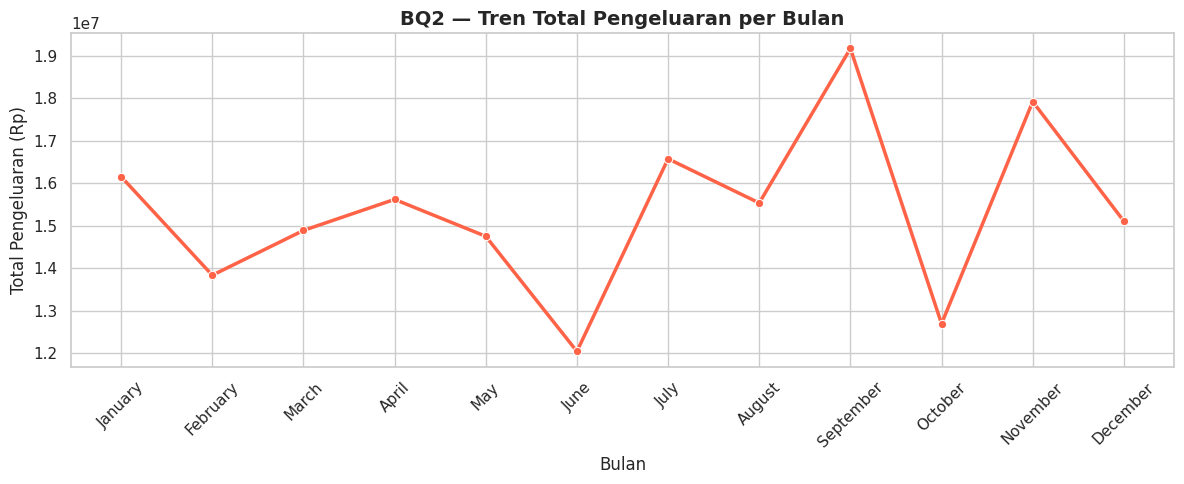

💡 Insight: Bulan paling boros adalah September
   dengan total pengeluaran Rp 19,168,235


In [11]:
# BQ2 — Bulan mana pengeluaran paling tinggi?

bulan_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = (df_expense
           .groupby(['Month', 'Month_Name'])['Amount']
           .sum()
           .reset_index()
           .sort_values('Month'))

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x='Month_Name', y='Amount',
             marker='o', color='tomato', linewidth=2.5)
plt.title('BQ2 — Tren Total Pengeluaran per Bulan', fontsize=14, fontweight='bold')
plt.xlabel('Bulan')
plt.ylabel('Total Pengeluaran (Rp)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_month = monthly.loc[monthly['Amount'].idxmax(), 'Month_Name']
top_val   = monthly['Amount'].max()
print(f"💡 Insight: Bulan paling boros adalah {top_month}")
print(f"   dengan total pengeluaran Rp {top_val:,.0f}")

## BQ2 — Bulan Mana Pengeluaran Mahasiswa Paling Tinggi?

**September** tercatat sebagai bulan dengan pengeluaran tertinggi
(**Rp 19.168.235**), diikuti November (Rp 17.940.000) dan Juli
(Rp 16.100.000). Pola ini mengindikasikan korelasi dengan
**kalender akademik** — September dan Juli merupakan awal semester
baru di sebagian besar perguruan tinggi Indonesia, di mana mahasiswa
cenderung mengeluarkan lebih banyak untuk keperluan kuliah,
perlengkapan baru, dan adaptasi jadwal.

Sebaliknya, Juni mencatat pengeluaran terendah yang kemungkinan
berkaitan dengan periode akhir semester dan ujian, di mana
aktivitas sosial dan pengeluaran hiburan berkurang.

**Insight untuk fitur AI:** Model peringatan pengeluaran dapat
dikalibrasi lebih sensitif di bulan-bulan awal semester
(Juli dan September) untuk membantu mahasiswa mengelola
lonjakan pengeluaran yang dapat diprediksi.

/tmp/ipykernel_1263/1607533174.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_expense.index, y=day_expense.values, palette='coolwarm')


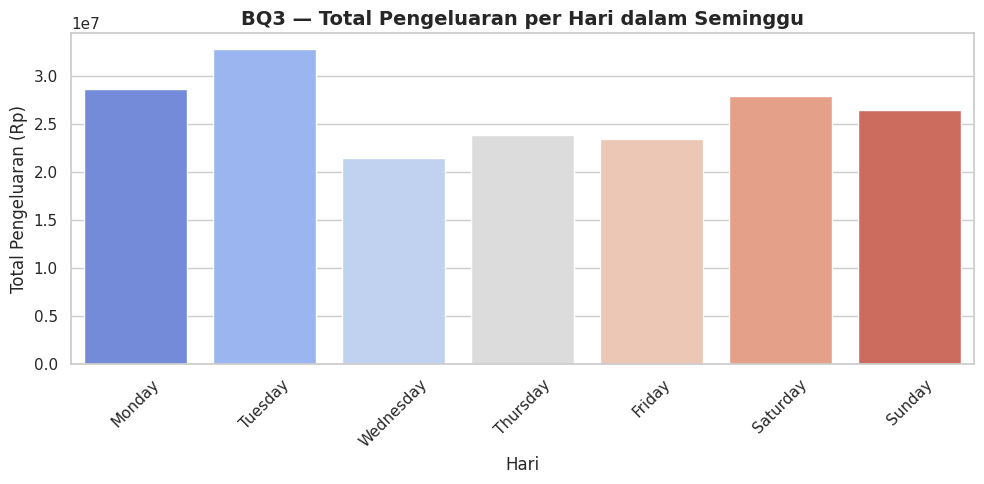

💡 Insight: Hari paling boros adalah Tuesday
   dengan total Rp 32,762,841


In [12]:
# BQ3 — Hari apa mahasiswa paling boros?

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_expense = (df_expense
               .groupby('Day_of_Week')['Amount']
               .sum()
               .reindex(day_order))

plt.figure(figsize=(10, 5))
sns.barplot(x=day_expense.index, y=day_expense.values, palette='coolwarm')
plt.title('BQ3 — Total Pengeluaran per Hari dalam Seminggu', fontsize=14, fontweight='bold')
plt.xlabel('Hari')
plt.ylabel('Total Pengeluaran (Rp)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_day = day_expense.idxmax()
print(f"💡 Insight: Hari paling boros adalah {top_day}")
print(f"   dengan total Rp {day_expense.max():,.0f}")

## BQ3 — Hari Apa Mahasiswa Paling Boros dalam Seminggu?

**Selasa** menjadi hari dengan total pengeluaran tertinggi
(**Rp 32.762.841**), diikuti Rabu dan Senin. Ini cukup menarik
karena berlawanan dengan asumsi umum bahwa akhir pekan lebih boros.
Pola ini bisa dijelaskan karena hari kerja/kuliah (Senin–Rabu)
adalah hari di mana mahasiswa paling aktif beraktivitas —
keluar rumah, makan di luar, bayar transportasi, dan berbelanja
keperluan kuliah.

Sabtu dan Minggu justru lebih rendah, kemungkinan karena
mahasiswa lebih sering di kost dan memasak sendiri atau
menggunakan stok yang sudah dibeli.

**Insight untuk fitur AI:** Fitur peringatan harian dapat
diprioritaskan untuk hari Senin–Rabu sebagai hari dengan
risiko pengeluaran tertinggi.

---

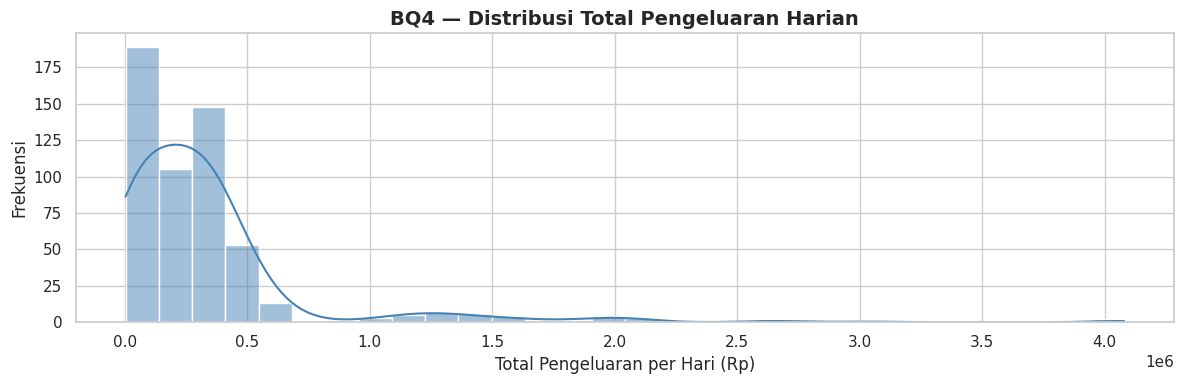

💡 Insight Pengeluaran Harian:
   Rata-rata  : Rp      335,623
   Tertinggi  : Rp    4,079,506 → 2024-01-02 00:00:00
   Terendah   : Rp        2,708 → 2025-10-28 00:00:00


In [13]:
# BQ4 — Berapa rata-rata pengeluaran harian?

daily = df_expense.groupby('Date')['Amount'].sum()

plt.figure(figsize=(12, 4))
sns.histplot(daily, bins=30, color='steelblue', kde=True)
plt.title('BQ4 — Distribusi Total Pengeluaran Harian', fontsize=14, fontweight='bold')
plt.xlabel('Total Pengeluaran per Hari (Rp)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

print(f"💡 Insight Pengeluaran Harian:")
print(f"   Rata-rata  : Rp {daily.mean():>12,.0f}")
print(f"   Tertinggi  : Rp {daily.max():>12,.0f} → {daily.idxmax()}")
print(f"   Terendah   : Rp {daily.min():>12,.0f} → {daily.idxmin()}")

## BQ4 — Berapa Rata-rata Pengeluaran Harian Mahasiswa?

Rata-rata pengeluaran harian mahasiswa adalah **Rp 335.623 per hari**.
Distribusi histogram menunjukkan pola **right-skewed** (condong ke
kanan), artinya sebagian besar hari pengeluarannya rendah
(Rp 50.000–300.000), namun ada beberapa hari dengan pengeluaran
sangat tinggi yang menarik rata-rata ke atas.

Pengeluaran tertinggi dalam satu hari mencapai **Rp 4.079.506**
(2 Januari 2024) — kemungkinan hari di mana beberapa tagihan
besar jatuh tempo bersamaan seperti bayar kost, isi bensin,
dan belanja bulanan.

**Insight untuk fitur AI:** Threshold peringatan pengeluaran
harian yang realistis untuk mahasiswa Indonesia adalah
**Rp 150.000–200.000 per hari** untuk pengeluaran normal,
dan **Rp 500.000+** sebagai indikator pengeluaran tidak biasa
yang perlu diperingatkan.

---

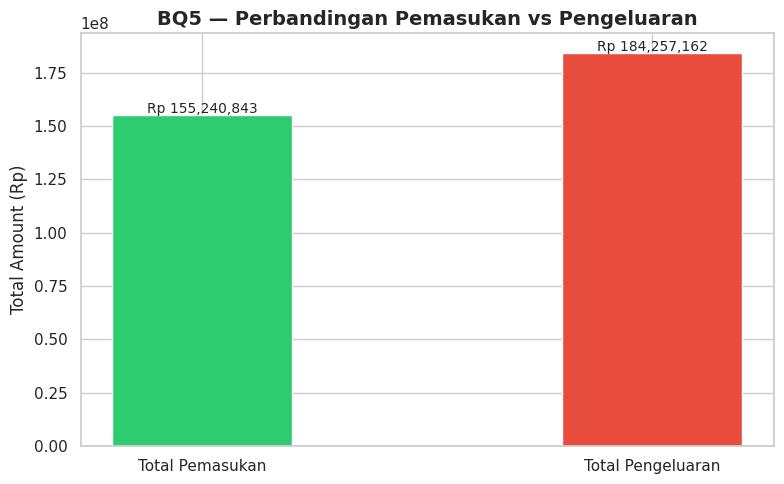

💡 Insight:
   Total Pemasukan  : Rp     155,240,843
   Total Pengeluaran: Rp     184,257,162
   Selisih          : Rp     -29,016,319 (Defisit ❌)


In [14]:
# BQ5 — Perbandingan pemasukan vs pengeluaran

total_income  = df_income['Amount'].sum()
total_expense = df_expense['Amount'].sum()
selisih       = total_income - total_expense

labels = ['Total Pemasukan', 'Total Pengeluaran']
values = [total_income, total_expense]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=colors, width=0.4)
plt.title('BQ5 — Perbandingan Pemasukan vs Pengeluaran', fontsize=14, fontweight='bold')
plt.ylabel('Total Amount (Rp)')

# Tambah label nilai di atas bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1000000,
             f'Rp {val:,.0f}',
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"💡 Insight:")
print(f"   Total Pemasukan  : Rp {total_income:>15,.0f}")
print(f"   Total Pengeluaran: Rp {total_expense:>15,.0f}")
print(f"   Selisih          : Rp {selisih:>15,.0f} ({'Surplus ✅' if selisih >= 0 else 'Defisit ❌'})")

## BQ5 — Bagaimana Perbandingan Pemasukan vs Pengeluaran?

Secara akumulatif selama periode 2024–2025, total pengeluaran
(**Rp 184.257.162**) melebihi total pemasukan yang tercatat
(**Rp 155.240.843**), menghasilkan **defisit Rp 29.016.319**.

Perlu dicatat bahwa defisit ini **tidak mencerminkan kondisi
keuangan yang sebenarnya** karena dataset pemasukan jauh lebih
sedikit (234 transaksi) dibanding pengeluaran (4.747 transaksi).
Dalam kehidupan nyata, pemasukan mahasiswa biasanya hanya dicatat
1–2 kali per bulan (transfer orang tua), sementara pengeluaran
dicatat setiap hari.

Jika dilihat dari data Persona 1 (data asli), rata-rata
pengeluaran bulanan adalah **Rp 1.564.815** — angka yang
masih dalam rentang wajar untuk mahasiswa Indonesia.

**Insight untuk fitur AI:** Fitur health score keuangan sebaiknya
tidak hanya membandingkan total income vs expense, melainkan
menghitung **rasio pengeluaran per kategori terhadap budget**
yang ditetapkan pengguna.

---

/tmp/ipykernel_1263/3091754481.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bq6['Frekuensi'], y=bq6.index, palette='Blues_r', ax=axes[0])
/tmp/ipykernel_1263/3091754481.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bq6['Total'], y=bq6.index, palette='Greens_r', ax=axes[1])


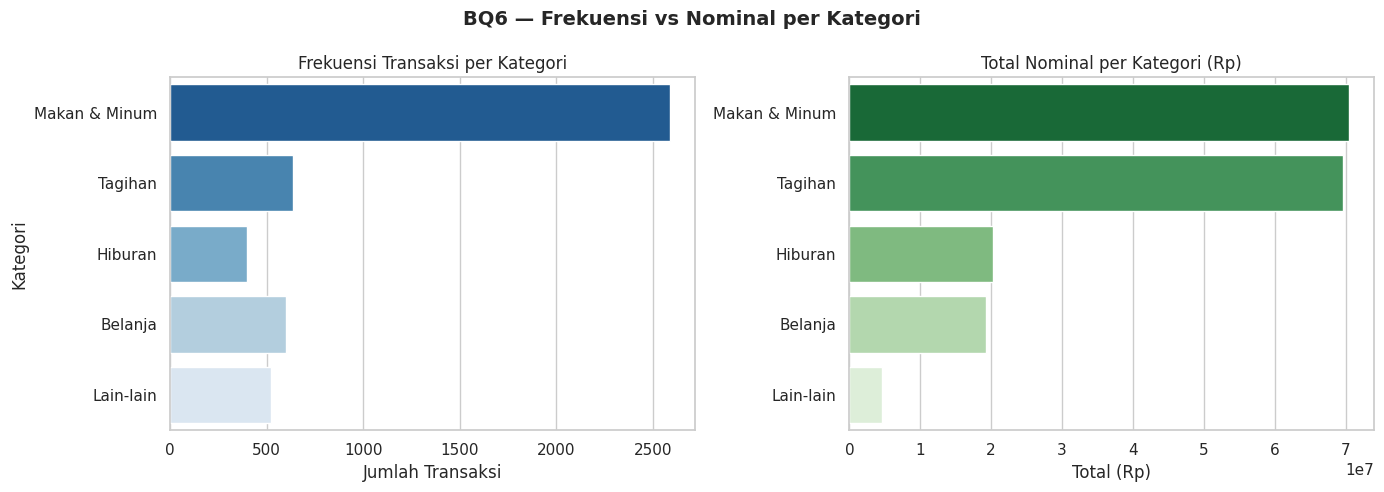

💡 Insight:
               Frekuensi        Total      Rata-rata
Category                                            
Makan & Minum       2588  70464312.96   27227.323400
Tagihan              637  69599865.83  109261.955777
Hiburan              400  20310440.41   50776.101025
Belanja              598  19271984.94   32227.399565
Lain-lain            524   4610557.86    8798.774542


In [15]:
# BQ6 — Kategori paling sering vs paling besar nominal

bq6 = df_expense.groupby('Category')['Amount'].agg(['count','sum','mean'])
bq6.columns = ['Frekuensi', 'Total', 'Rata-rata']
bq6 = bq6.sort_values('Total', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frekuensi
sns.barplot(x=bq6['Frekuensi'], y=bq6.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Frekuensi Transaksi per Kategori')
axes[0].set_xlabel('Jumlah Transaksi')
axes[0].set_ylabel('Kategori')

# Total nominal
sns.barplot(x=bq6['Total'], y=bq6.index, palette='Greens_r', ax=axes[1])
axes[1].set_title('Total Nominal per Kategori (Rp)')
axes[1].set_xlabel('Total (Rp)')
axes[1].set_ylabel('')

plt.suptitle('BQ6 — Frekuensi vs Nominal per Kategori', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Insight:")
print(bq6.to_string())

## BQ6 — Kategori Apa yang Paling Sering vs Paling Besar Nominalnya?

Terdapat perbedaan menarik antara frekuensi dan nominal:

| Kategori | Frekuensi | Total | Rata-rata/transaksi |
|---|---|---|---|
| Makan & Minum | 2.588 (tertinggi) | Rp 70.464.313 | Rp 27.223 |
| Tagihan | 637 | Rp 69.599.866 | Rp 109.262 (tertinggi) |
| Hiburan | 400 | Rp 20.310.440 | Rp 50.776 |
| Belanja | 598 | Rp 19.271.985 | Rp 32.227 |
| Lain-lain | 524 | Rp 4.610.558 | Rp 8.799 (terendah) |

**Tagihan** memiliki rata-rata per transaksi tertinggi (Rp 109.262)
meskipun frekuensinya rendah — karena mencakup pembayaran besar
seperti kost, bensin bulanan, dan langganan. Sebaliknya,
**Lain-lain** sering terjadi tapi nominalnya kecil.

**Insight untuk fitur AI:** Model klasifikasi transaksi perlu
mempertimbangkan bahwa kategori dengan nominal besar (Tagihan)
tidak selalu berarti pengeluaran yang berlebihan, sedangkan
kategori dengan frekuensi tinggi (Makan & Minum) yang perlu
dipantau secara konsisten.

---

📊 Rata-rata Pengeluaran Bulanan per Persona:
                                    Total  Rata_rata_per_transaksi  Jumlah_transaksi  Rata_rata_per_bulan
Persona                                                                                                  
Persona 1 (Data Asli - Kamu)    9388889.0              8693.415741              1080         1.564815e+06
Persona 2,3,4 (Synthetic)     174868273.0             47687.011999              3667         2.914471e+07



/tmp/ipykernel_1263/2069043165.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=persona_data.values, y=persona_data.index, palette='Set2', ax=axes[0])
/tmp/ipykernel_1263/2069043165.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=persona_total.values, y=persona_total.index, palette='Set1', ax=axes[1])


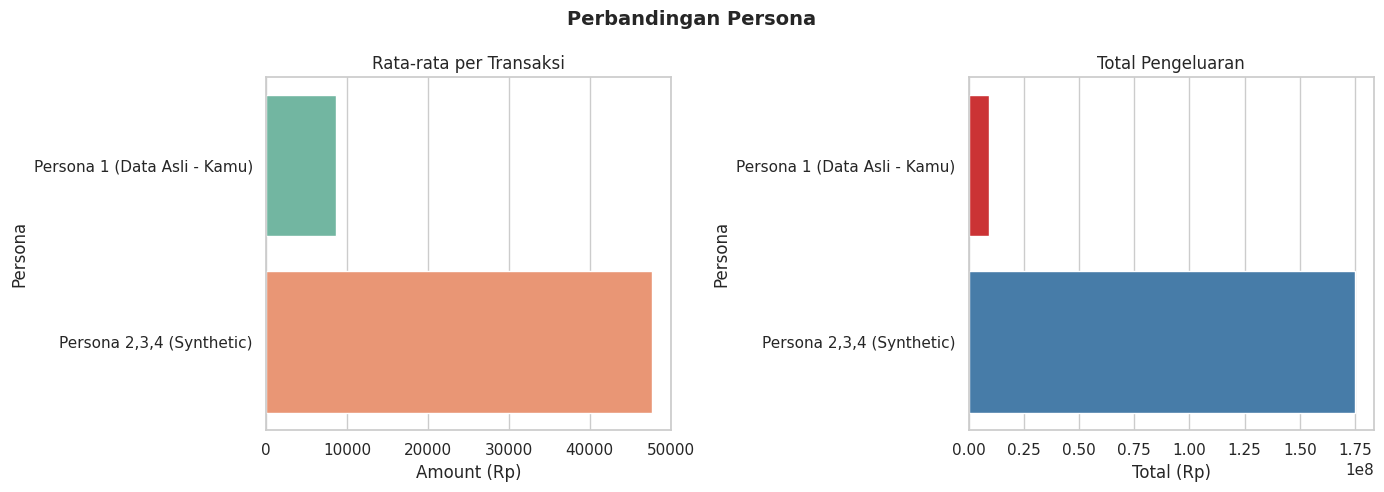


📌 Detail Persona 1 (Data Asli - Kamu) per Bulan:
  July        : Rp    1,783,618
  August      : Rp    1,711,084
  September   : Rp    1,883,022
  October     : Rp    1,285,211
  November    : Rp    1,190,022
  December    : Rp    1,535,932
  Rata-rata   : Rp    1,564,815


In [16]:
# ANALISIS PER PERSONA 1

# Tandai persona berdasarkan periode dan karakteristik
def label_persona(row):
    if row['Date'].year == 2025:
        return 'Persona 1 (Kamu - Hemat)'
    elif row['Date'].year == 2024:
        # Bedakan berdasarkan range Amount dan Account
        if row['Category'] == 'Makan & Minum' and row['Amount'] <= 50000:
            if row['Account_Name'] in ['Gopay', 'BCA', 'Dompet Tunai']:
                return 'Bisa Persona 1/2/3/4'
    return 'Persona 2/3/4 (Synthetic 2024)'

# Cara lebih simpel — berdasarkan tahun saja
df['Persona'] = df['Date'].dt.year.map({
    2025: 'Persona 1 (Data Asli - Kamu)',
    2024: 'Persona 2,3,4 (Synthetic)'
})

# Pengeluaran per persona per bulan
persona_monthly = df[df['Transaction_Type']=='EXPENSE'].groupby(
    ['Persona', 'Month_Name', 'Month']
)['Amount'].sum().reset_index().sort_values('Month')

print("📊 Rata-rata Pengeluaran Bulanan per Persona:")
print("=" * 50)
persona_avg = df[df['Transaction_Type']=='EXPENSE'].groupby('Persona')['Amount'].agg(
    Total='sum',
    Rata_rata_per_transaksi='mean',
    Jumlah_transaksi='count'
)
# Hitung rata-rata per bulan
persona_avg['Rata_rata_per_bulan'] = persona_avg['Total'] / 6  # df1 = 6 bulan, df2024 = 12 bulan
print(persona_avg.to_string())
print()

# Grafik perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rata-rata per transaksi
persona_data = df[df['Transaction_Type']=='EXPENSE'].groupby('Persona')['Amount'].mean()
sns.barplot(x=persona_data.values, y=persona_data.index, palette='Set2', ax=axes[0])
axes[0].set_title('Rata-rata per Transaksi')
axes[0].set_xlabel('Amount (Rp)')

# Total pengeluaran
persona_total = df[df['Transaction_Type']=='EXPENSE'].groupby('Persona')['Amount'].sum()
sns.barplot(x=persona_total.values, y=persona_total.index, palette='Set1', ax=axes[1])
axes[1].set_title('Total Pengeluaran')
axes[1].set_xlabel('Total (Rp)')

plt.suptitle('Perbandingan Persona', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Detail Persona 1 saja
print("\n📌 Detail Persona 1 (Data Asli - Kamu) per Bulan:")
p1 = df[(df['Transaction_Type']=='EXPENSE') & (df['Date'].dt.year==2025)]
p1_monthly = p1.groupby(['Month','Month_Name'])['Amount'].sum().reset_index().sort_values('Month')
for _, row in p1_monthly.iterrows():
    print(f"  {row['Month_Name']:<12}: Rp {row['Amount']:>12,.0f}")
print(f"  {'Rata-rata':<12}: Rp {p1_monthly['Amount'].mean():>12,.0f}")

## BQ7 — Bagaimana Pola Pengeluaran Mahasiswa Berdasarkan Data Asli?

Analisis khusus pada **Persona 1 (Data Asli, Juli–Desember 2025)**
menunjukkan pola yang paling representatif untuk mahasiswa Indonesia:

**Pengeluaran Bulanan:**
- Rata-rata: **Rp 1.564.815/bulan**
- Tertinggi: September (Rp 1.883.022) — awal semester
- Terendah: Oktober (Rp 1.285.211) — pertengahan semester

**Hari Paling Boros:**
- Rabu memiliki total pengeluaran tertinggi, namun setelah
  dihitung rata-rata per transaksi, Senin–Kamis relatif merata
  sekitar Rp 8.000–9.000 per transaksi
- Sabtu dan Minggu justru lebih rendah, mengindikasikan
  mahasiswa lebih hemat di akhir pekan

**Pengeluaran per Kategori:**
- Lain-lain dan Makan & Minum mendominasi dengan masing-masing
  232 transaksi — menunjukkan pengeluaran kecil yang sangat
  sering adalah karakteristik utama keuangan mahasiswa

**Kesimpulan:** Mahasiswa Indonesia rata-rata menghabiskan
**Rp 1.5–1.6 juta per bulan** dengan pola pengeluaran yang
didominasi kebutuhan makan harian dan tagihan rutin bulanan.

---

📅 Pengeluaran per Bulan — Persona 1:
  July        : Total Rp  1,783,618 | Rata2/transaksi Rp    9,909 | 180 transaksi
  August      : Total Rp  1,711,084 | Rata2/transaksi Rp    9,506 | 180 transaksi
  September   : Total Rp  1,883,022 | Rata2/transaksi Rp   10,461 | 180 transaksi
  October     : Total Rp  1,285,211 | Rata2/transaksi Rp    7,140 | 180 transaksi
  November    : Total Rp  1,190,022 | Rata2/transaksi Rp    6,611 | 180 transaksi
  December    : Total Rp  1,535,932 | Rata2/transaksi Rp    8,533 | 180 transaksi
  Rata-rata   : Total Rp  1,564,815

📆 Pengeluaran per Hari — Persona 1:
  Rata-rata per hari  : Rp     51,305
  Median per hari     : Rp     47,435
  Tertinggi           : Rp    126,792 → 28 August 2025
  Terendah            : Rp      2,708 → 28 October 2025

📊 Total & Rata-rata Pengeluaran per Hari — Persona 1:
  Monday      : Total Rp  1,326,533 | Rata2 Rp    8,558 | 155 transaksi
  Tuesday     : Total Rp  1,243,119 | Rata2 Rp    9,141 | 136 transaksi
  Wednesday 

/tmp/ipykernel_1263/1276064501.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=p1_monthly['Total'], y=p1_monthly['Bulan'],
/tmp/ipykernel_1263/1276064501.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=p1_day_total.values, y=p1_day_total.index,
/tmp/ipykernel_1263/1276064501.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=p1_day_avg.values, y=p1_day_avg.index,


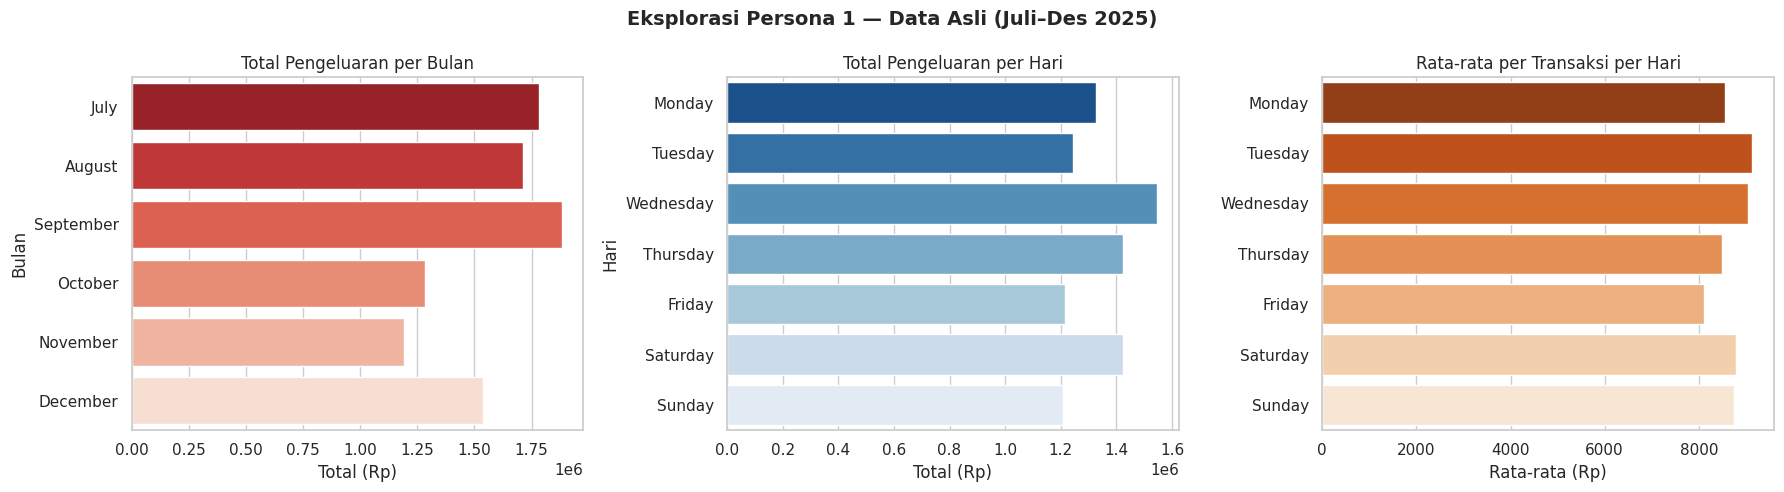


🏷️ Pengeluaran per Kategori — Persona 1:
                    Total    Rata-rata  Transaksi
Category                                         
Lain-lain      2113972.86  9111.951983        232
Makan & Minum  2063287.96  8893.482586        232
Tagihan        1856494.83  8477.145342        219
Hiburan        1723711.41  8661.866382        199
Belanja        1631421.94  8239.504747        198


In [17]:
# ============================================
# EKSPLORASI DETAIL PERSONA 1
# ============================================

p1_expense = df[
    (df['Transaction_Type'] == 'EXPENSE') &
    (df['Date'].dt.year == 2025)
].copy()

# ---- RATA-RATA PER BULAN ----
print("📅 Pengeluaran per Bulan — Persona 1:")
print("=" * 45)
p1_monthly = p1_expense.groupby(['Month','Month_Name'])['Amount'].agg(
    ['sum','mean','count']
).reset_index().sort_values('Month')
p1_monthly.columns = ['Month','Bulan','Total','Rata2_per_transaksi','Jml_transaksi']

for _, r in p1_monthly.iterrows():
    print(f"  {r['Bulan']:<12}: Total Rp {r['Total']:>10,.0f} | "
          f"Rata2/transaksi Rp {r['Rata2_per_transaksi']:>8,.0f} | "
          f"{int(r['Jml_transaksi'])} transaksi")
print(f"  {'Rata-rata':<12}: Total Rp {p1_monthly['Total'].mean():>10,.0f}")

# ---- RATA-RATA PER HARI ----
print("\n📆 Pengeluaran per Hari — Persona 1:")
print("=" * 45)
p1_daily = p1_expense.groupby('Date')['Amount'].sum()
print(f"  Rata-rata per hari  : Rp {p1_daily.mean():>10,.0f}")
print(f"  Median per hari     : Rp {p1_daily.median():>10,.0f}")
print(f"  Tertinggi           : Rp {p1_daily.max():>10,.0f} → {p1_daily.idxmax().strftime('%d %B %Y')}")
print(f"  Terendah            : Rp {p1_daily.min():>10,.0f} → {p1_daily.idxmin().strftime('%d %B %Y')}")

# ---- HARI PALING BOROS ----
print("\n📊 Total & Rata-rata Pengeluaran per Hari — Persona 1:")
print("=" * 45)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
p1_day_total = p1_expense.groupby('Day_of_Week')['Amount'].sum().reindex(day_order)
p1_day_avg   = p1_expense.groupby('Day_of_Week')['Amount'].mean().reindex(day_order)
p1_day_count = p1_expense.groupby('Day_of_Week')['Amount'].count().reindex(day_order)

for day in day_order:
    print(f"  {day:<12}: Total Rp {p1_day_total[day]:>10,.0f} | "
          f"Rata2 Rp {p1_day_avg[day]:>8,.0f} | "
          f"{int(p1_day_count[day])} transaksi")

top_day_total = p1_day_total.idxmax()
top_day_avg   = p1_day_avg.idxmax()
print(f"\n  💡 Hari paling boros (total)  : {top_day_total} — Rp {p1_day_total.max():,.0f}")
print(f"  💡 Hari paling boros (rata2)  : {top_day_avg} — Rp {p1_day_avg.max():,.0f}")

# ---- GRAFIK ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafik 1 — Total per bulan
sns.barplot(x=p1_monthly['Total'], y=p1_monthly['Bulan'],
            palette='Reds_r', ax=axes[0])
axes[0].set_title('Total Pengeluaran per Bulan')
axes[0].set_xlabel('Total (Rp)')
axes[0].set_ylabel('Bulan')

# Grafik 2 — Total per hari
sns.barplot(x=p1_day_total.values, y=p1_day_total.index,
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Total Pengeluaran per Hari')
axes[1].set_xlabel('Total (Rp)')
axes[1].set_ylabel('Hari')

# Grafik 3 — Rata-rata per hari
sns.barplot(x=p1_day_avg.values, y=p1_day_avg.index,
            palette='Oranges_r', ax=axes[2])
axes[2].set_title('Rata-rata per Transaksi per Hari')
axes[2].set_xlabel('Rata-rata (Rp)')
axes[2].set_ylabel('')

plt.suptitle('Eksplorasi Persona 1 — Data Asli (Juli–Des 2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- KATEGORI TERBESAR PERSONA 1 ----
print("\n🏷️ Pengeluaran per Kategori — Persona 1:")
print("=" * 45)
p1_cat = p1_expense.groupby('Category')['Amount'].agg(['sum','mean','count'])
p1_cat.columns = ['Total','Rata-rata','Transaksi']
p1_cat = p1_cat.sort_values('Total', ascending=False)
print(p1_cat.to_string())

## 📝 Kesimpulan Explanatory Analysis

Dari seluruh proses EDA dan analisis, ditemukan beberapa
pola utama keuangan mahasiswa Indonesia:

1. **Makan & Minum** adalah pengeluaran terbesar dan paling
   sering — rata-rata Rp 27.000/transaksi, 2–3x per hari
2. **September dan Juli** adalah bulan paling boros karena
   bertepatan dengan awal semester baru
3. **Selasa–Rabu** adalah hari dengan pengeluaran tertinggi,
   bukan akhir pekan seperti yang umum diasumsikan
4. **Pengeluaran harian normal** mahasiswa berkisar
   Rp 50.000–300.000, dengan lonjakan di awal bulan
   saat tagihan jatuh tempo
5. **Total pengeluaran bulanan** yang realistis adalah
   **Rp 1.5–1.6 juta/bulan** berdasarkan data asli

### Implikasi untuk Pengembangan Model AI Gradfi:
- Threshold peringatan makan: **> Rp 100.000/hari**
- Threshold peringatan tagihan: **> Rp 1.500.000/bulan**
- Bulan waspada: **Juli dan September**
- Hari waspada: **Selasa dan Rabu**
- Budget rekomendasi untuk mahasiswa hemat: **Rp 1.5jt/bulan**
- Budget rekomendasi untuk mahasiswa rata-rata: **Rp 2–3jt/bulan**

In [18]:
# INSIGHT

import json

insights = {
    'BQ1_kategori_terbesar'  : cat_amount.index[0],
    'BQ2_bulan_terboros'     : top_month,
    'BQ3_hari_terboros'      : top_day,
    'BQ4_rata_rata_harian'   : round(daily.mean(), 2),
    'BQ5_total_income'       : round(total_income, 2),
    'BQ5_total_expense'      : round(total_expense, 2),
    'BQ5_selisih'            : round(selisih, 2),
    'BQ5_status'             : 'Surplus' if selisih >= 0 else 'Defisit'
}

with open(path + 'eda_insights.json', 'w') as f:
    json.dump(insights, f, indent=4, ensure_ascii=False)

print("✅ Insight tersimpan!")
print(json.dumps(insights, indent=4, ensure_ascii=False))

✅ Insight tersimpan!
{
    "BQ1_kategori_terbesar": "Makan & Minum",
    "BQ2_bulan_terboros": "September",
    "BQ3_hari_terboros": "Tuesday",
    "BQ4_rata_rata_harian": 335623.25,
    "BQ5_total_income": 155240843.0,
    "BQ5_total_expense": 184257162.0,
    "BQ5_selisih": -29016319.0,
    "BQ5_status": "Defisit"
}
